In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

2025-09-22 16:49:26.585496: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-22 16:49:26.590520: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-22 16:49:26.601359: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758530966.620032  382960 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758530966.625832  382960 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758530966.640173  382960 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
tf.__version__

'2.19.1'

In [3]:
# load and preprocess CIFAR-10 data
# https://www.tensorflow.org/datasets/catalog/cifar10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [4]:
# Normalize pixel values
train_images, test_images = train_images / 255.0, test_images / 255.0

In [5]:
# define a CNN model
model = models.Sequential([
    # Convolutional Layer 1: 32 filters, 3x3 kernel, ReLU activation
    layers.Conv2D(32, (3, 3), activation = "relu", input_shape = (32, 32, 3)),
    # Max Pooling: 2x2 window
    layers.MaxPool2D((2, 2)),

    # Convolutional Layer 2: 64 filters, 3x3 kernel
    layers.Conv2D(64, (3, 3), activation = "relu"),
    layers.MaxPool2D((2, 2)),

    # Convolutional Layer 3:
    layers.Conv2D(64, (3, 3), activation = "relu"),

    # Flatten the feature maps
    layers.Flatten(),
    
    # Fully Connected Layer: 64 neurons
    layers.Dense(64, activation = "relu"),
    
    # Output Layer: 10 classes
    layers.Dense(10)
])

# compile the model
model.compile(optimizer = "adam",
             loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
             metrics = ["accuracy"])

/home/xcql/uGALpXeP4FEJ9iPi/Projects/github.com/data-science-and-machine-learning-cheat-sheet/env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-22 16:49:34.652300: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
# train the model
history = model.fit(train_images, train_labels, epochs = 10, validation_data = (test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.3572 - loss: 1.7307 - val_accuracy: 0.5356 - val_loss: 1.2871
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.5753 - loss: 1.1933 - val_accuracy: 0.6316 - val_loss: 1.0484
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6562 - loss: 0.9779 - val_accuracy: 0.6521 - val_loss: 0.9992
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6940 - loss: 0.8753 - val_accuracy: 0.6670 - val_loss: 0.9648
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.7194 - loss: 0.7937 - val_accuracy: 0.6821 - val_loss: 0.9234
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7430 - loss: 0.7294 - val_accuracy: 0.6971 - val_loss: 0.9050
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7629 - loss: 0.6734 - val_accuracy: 0.6987 - val_loss: 0.8831
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.7841 -

In [7]:
# evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose = 2)
print(f"Test Accuracy: {test_acc:.2f}")

313/313 - 2s - 5ms/step - accuracy: 0.7053 - loss: 0.9368
Test Accuracy: 0.71


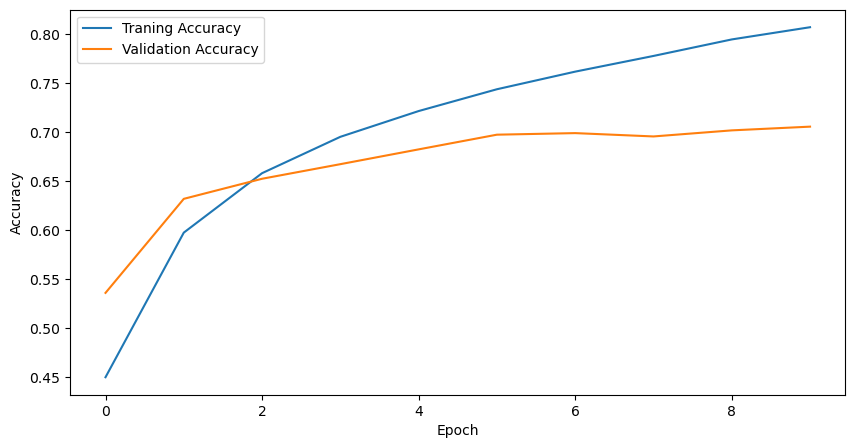

In [8]:
import matplotlib.pyplot as plt

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()